In [1]:
import os

from getdist import plots, loadMCSamples
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use(
    "/home/guerrini/matplotlib_config/paper.mplstyle"
)

sns.set_palette("husl")

g = plots.get_single_plotter(width_inch=30)

%matplotlib inline

#SPECIFY DATA DIRECTORY AND DESIRED CHAINS TO ANALYSE
root_dir = "/n09data/guerrini/output_chains/"
root_external = "/n09data/guerrini/output_chains/ext_data/"

roots = [
    "SP_v1.4.6_leak_corr_A_lmin=300_lmax=1600_cell",
    "SP_v1.4.6_leak_corr_A_10_80",
    "DES_Y3",
    "KiDS-1000",
    "HSC_Y3",
    "DES+KiDS"
]

categories = [
    "harmonic",
    "configuration",
    "external",
    "external",
    "external",
    "external"
]

print(roots)

os.makedirs("plots", exist_ok=True)
os.makedirs("plots/cosmological_constraints_weak_lensing", exist_ok=True)

['SP_v1.4.6_leak_corr_A_lmin=300_lmax=1600_cell', 'SP_v1.4.6_leak_corr_A_10_80', 'DES_Y3', 'KiDS-1000', 'HSC_Y3', 'DES+KiDS']


In [2]:
# MAKE PARAMNAMES FILE

for i, root in enumerate(roots):
    if categories[i] != "external":
        with open(root_dir + '{}/samples_{}.txt'.format('/'+root ,root), "r") as file:
            params = file.readline()[1:].split('\t')[:-4]
            file.close()
    
        with open(root_dir + '{}/getdist_{}.paramnames'.format('/'+root, root), "w") as file:
            for i in range(len(params)):
                if len(params[i].split('--')) > 1:
                    file.write(params[i].split('--')[1] + '\n')
                else:
                    file.write(params[i].split('--')[0] + '\n')
            file.close()

In [3]:
#READ CHAIN

chains=[]

for i, root in enumerate(roots):

    if categories[i] != "external":
        samples = np.loadtxt(root_dir + '{}/samples_{}.txt'.format(root,root))
        print(len(samples))
        if 'nautilus' in root:
            samples = np.column_stack((np.exp(samples[:,-3]),samples[:,-1]-samples[:,-2],samples[:,0:-3]))
        else:
            samples = np.column_stack((samples[:,-1],samples[:,-3],samples[:,0:-4]))
        np.savetxt(root_dir + '{}/getdist_{}.txt'.format(root,root), samples)

    root_dir_ = root_external if categories[i]=="external" else root_dir
    
    chain = g.samples_for_root(root_dir_ + '{}/getdist_{}'.format(root,root),
                               cache=False,
                               settings={'ignore_rows':0,
                                         'smooth_scale_2D':0.5,
                                         'smooth_scale_1D':0.5})

    chains.append(chain)

1420
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_lmin=300_lmax=1600_cell/getdist_SP_v1.4.6_leak_corr_A_lmin=300_lmax=1600_cell.txt
Removed no burn in
1618
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_10_80/getdist_SP_v1.4.6_leak_corr_A_10_80.txt
Removed no burn in


In [4]:
name_list = ['OMEGA_M','ombh2','h0','n_s','SIGMA_8', 'S_8', 's_8_input', 'logt_agn','a','m1','bias_1']
label_list = ['\Omega_m', '\omega_b h^2', 'h_0', 'n_s', '\sigma_8', 'S_8', 'S_8', 'log T_{AGN}', 'A_{IA}', 'm_1', '\Delta z_1']

for chain in chains:
    param_names = chain.getParamNames()
    for name, label in zip(name_list, label_list):
        try:
            param_names.parWithName(name).label = label
        except:
            pass

In [5]:
def adjust_paramname_chain(chain, current_name, target_name, label):
    """
    Adjusts the parameter name and label in a GetDist chain.
    """
    param_names = chain.getParamNames()
    par = param_names.parWithName(current_name)

    par.label = label
    par.name = target_name

    chain.setParamNames(param_names)

def derive_parameter_S8(chain):
    """
    Derives the S_8 parameter from Omega_m and Sigma_8 in a GetDist chain.
    S_8 = Sigma_8 * (Omega_m / 0.3) ** 0.5
    """
    omega_m = chain.getParams().OMEGA_M
    sigma_8 = chain.getParams().SIGMA_8

    s_8 = sigma_8 * (omega_m / 0.3) ** 0.5

    chain.addDerived(s_8, name='S_8', label='S_8')

    return chain
    


In [6]:
if 'KiDS-1000' in roots:
    idx = roots.index('KiDS-1000')
    adjust_paramname_chain(chains[idx], 'omega_m', 'OMEGA_M', '\Omega_m')

if 'HSC_Y3' in roots:
    idx = roots.index('HSC_Y3')
    adjust_paramname_chain(chains[idx], 'omega_m', 'OMEGA_M', '\Omega_m')

if 'DES+KiDS' in roots:
    idx = roots.index('DES+KiDS')
    adjust_paramname_chain(chains[idx], 'omega_m', 'OMEGA_M', '\Omega_m')

if 'DES_Y3' in roots:
    idx = roots.index('DES_Y3')
    adjust_paramname_chain(chains[idx], 'omega_m', 'OMEGA_M', '\Omega_m')
    derive_parameter_S8(chains[idx])

/tmp/ipykernel_1699749/2491715677.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("plots/cosmological_constraints_weak_lensing/contours_OMEGA_M_S8_2D_weak_lensing_all_surveys.png", dpi=300, bbox_inches='tight')
/tmp/ipykernel_1699749/2491715677.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("plots/cosmological_constraints_weak_lensing/contours_OMEGA_M_S8_2D_weak_lensing_all_surveys.pdf", bbox_inches='tight')


<Figure size 3000x2250 with 0 Axes>

/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


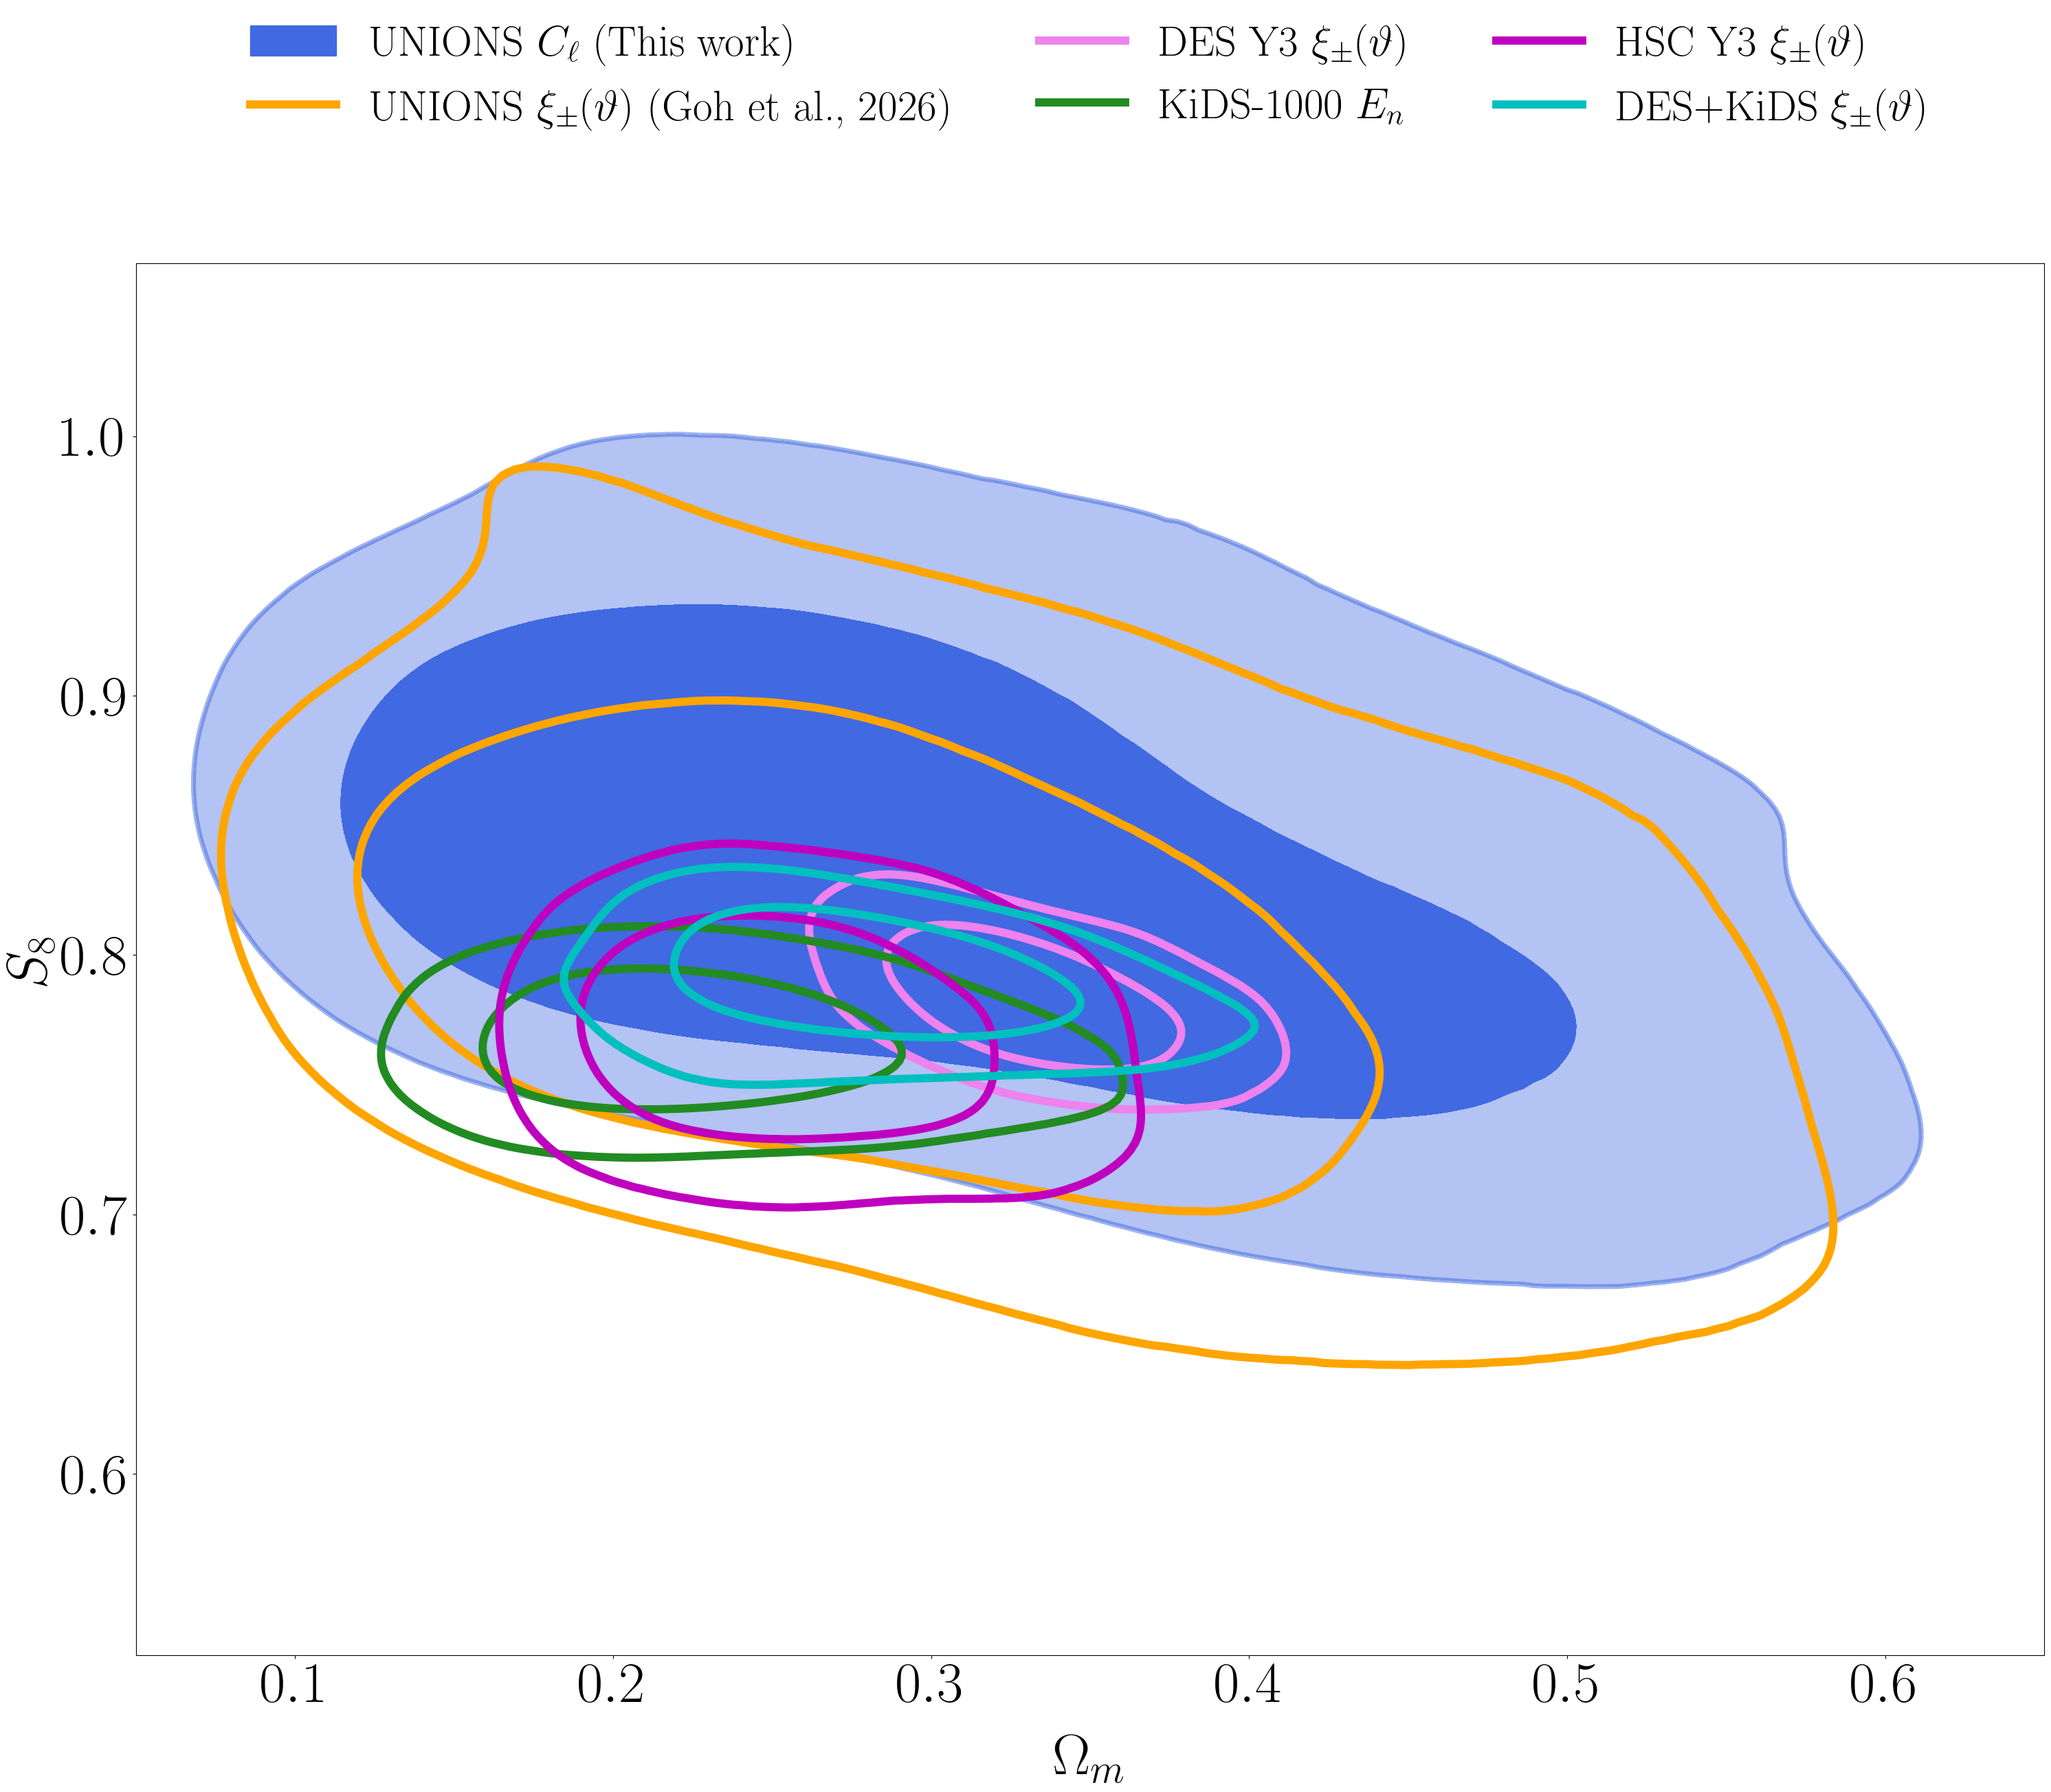

In [7]:
legend_labels = [
    r"UNIONS $C_\ell$ (This work)",
    r"UNIONS $\xi_\pm(\vartheta)$ (Goh et al., 2026)",
    r"DES Y3 $\xi_\pm(\vartheta)$",
    r"KiDS-1000 $E_n$",
    r"HSC Y3 $\xi_\pm(\vartheta)$",
    r"DES+KiDS $\xi_\pm(\vartheta)$"
]

colours = [
    "royalblue",
    "orange",
    "violet",
    "forestgreen",
]

linestyle = [
    'solid',
    'solid',
    'solid',
    'solid',
    'solid',
    'solid'
]

filled = [
    True,
    False,
    False,
    False,
    False,
    False
]

line_args = [dict(color=col, ls=ls) for col, ls in zip(colours, linestyle)]

g = plots.get_single_plotter(width_inch=30)
g.settings.axes_fontsize=60
g.settings.axes_labelsize=60
g.settings.alpha_filled_add = 0.7
g.settings.legend_fontsize = 45
g.settings.figure_legend_ncol = 3
g.settings.legend_frame = False

g.plot_2d(chains,
          'OMEGA_M', 'S_8',
          filled=filled,
          line_args=line_args,
          contour_colors=colours,)

g.add_legend(
    legend_labels,
    legend_loc='upper center',
    bbox_to_anchor=(0.5, 1.20),   # moves legend above the axes
)

plt.xlim(0.05, 0.65)

plt.savefig("plots/cosmological_constraints_weak_lensing/contours_OMEGA_M_S8_2D_weak_lensing_all_surveys.png", dpi=300, bbox_inches='tight')
#Save PDF
plt.savefig("plots/cosmological_constraints_weak_lensing/contours_OMEGA_M_S8_2D_weak_lensing_all_surveys.pdf", bbox_inches='tight')
plt.show()
